In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "src").exists():
    project_root = cwd
elif (cwd.parent / "src").exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError("Could not locate project root containing 'src'.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
import statsmodels.api as sm


In [ ]:

from src.data.create_dataframes import processed_df_map

pd.set_option("display.float_format", "{:,.4f}".format)

DEFAULT_Y_COL_MAP = {
    "eur_df_processed": "EURUSD",
    "gbp_df_processed": "GBPUSD",
    "jpy_df_processed": "USDJPY",
    "chf_df_processed": "USDCHF",
    "cad_df_processed": "USDCAD",
    "aud_df_processed": "AUDUSD",
    "nzd_df_processed": "NZDUSD",
    "nok_df_processed": "USDNOK",
    "sek_df_processed": "USDSEK",
}

def latest_window_multivariate_ols(df: pd.DataFrame, y_col: str, window: int = 252):
    """Fit multivariate OLS on the most recent rolling window and return (summary, r2)."""
    if y_col not in df.columns:
        raise KeyError(f"{y_col} not found in dataframe columns.")

    window_df = df.tail(window).dropna()
    if len(window_df) < 2:
        raise ValueError("Not enough non-NaN rows in the latest rolling window.")

    y = window_df[y_col]
    X = window_df.drop(columns=[y_col])
    X_const = sm.add_constant(X, has_constant="add")

    model = sm.OLS(y, X_const).fit()
    r2 = model.rsquared

    betas = model.params.drop("const")
    pvals = model.pvalues.drop("const")
    signif_pct = (1 - pvals) * 100

    ranked_idx = betas.abs().sort_values(ascending=False).index
    betas = betas.reindex(ranked_idx)
    signif_pct = signif_pct.reindex(ranked_idx)

    summary = pd.DataFrame({
        "Driver Name": betas.index,
        "Beta Coefficient": betas.values,
        "Rank": np.arange(1, len(betas) + 1),
        "Significance %": signif_pct.values,
    })
    summary["Beta Coefficient"] = summary["Beta Coefficient"].round(4)
    summary["Significance %"] = summary["Significance %"].round(2)
    return summary, r2

def run_processed_df_regression(df_name: str, y_col: str | None = None, window: int = 252):
    """Convenience wrapper for processed_df_map by name."""
    if df_name not in processed_df_map:
        raise KeyError(f"{df_name} not found in processed_df_map.")

    if y_col is None:
        y_col = DEFAULT_Y_COL_MAP.get(df_name)
        if y_col is None:
            raise KeyError(f"No default y_col found for {df_name}.")

    summary, r2 = latest_window_multivariate_ols(processed_df_map[df_name], y_col, window=window)
    display(summary)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return summary, r2




In [ ]:
sorted(processed_df_map.keys())


In [ ]:
# Example usage (default y_col is picked automatically)
run_processed_df_regression("nok_df_processed")


In [ ]:
def run_processed_df_regression_sig_only(
    df_name: str,
    y_col: str | None = None,
    window: int = 252,
    min_significance: float = 95.0,
):
    """Same as run_processed_df_regression but filters to >= min_significance."""
    summary, r2 = run_processed_df_regression(df_name, y_col=y_col, window=window)
    filtered = summary[summary["Significance %"] >= min_significance].reset_index(drop=True)
    display(filtered)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return filtered, r2

run_processed_df_regression_sig_only("aud_df_processed")



In [ ]:
from src.data.create_dataframes import build_df2_map, frames, fx_newdf

# Assume you have frames and fx_newdf already loaded
df2_map = build_df2_map(frames, fx_newdf)

# To get the dataframe:
nok_df2 = df2_map["nok_df2"]
aud_df2 = df2_map["aud_df2"]
eur_df2 = df2_map["eur_df2"]


In [ ]:
aud_df2.tail()

In [ ]:
from src.data.build_ultimate_df import build_ultimate_df

ultimate_df = build_ultimate_df()
ultimate_df["aud"].tail()


In [ ]:
nok_ultimate_df = ultimate_df["nok"]
nok_ultimate_df

In [ ]:
sek_ultimate_df = ultimate_df["sek"]
sek_ultimate_df

In [ ]:
from src.data.build_ultimate_df import build_ultimate_df

ultimate_df = build_ultimate_df()

pd.set_option("display.float_format", "{:,.4f}".format)

DEFAULT_Y_COL_MAP = {
    "eur": "EURUSD",
    "gbp": "GBPUSD",
    "jpy": "USDJPY",
    "chf": "USDCHF",
    "cad": "USDCAD",
    "aud": "AUDUSD",
    "nzd": "NZDUSD",
    "nok": "USDNOK",
    "sek": "USDSEK",
}

def latest_window_multivariate_ols(df: pd.DataFrame, y_col: str, window: int = 252):
    """Fit multivariate OLS on the most recent rolling window and return (summary, r2)."""
    if y_col not in df.columns:
        raise KeyError(f"{y_col} not found in dataframe columns.")

    window_df = df.tail(window).dropna()
    if len(window_df) < 2:
        raise ValueError("Not enough non-NaN rows in the latest rolling window.")

    y = window_df[y_col]
    X = window_df.drop(columns=[y_col])
    X_const = sm.add_constant(X, has_constant="add")

    model = sm.OLS(y, X_const).fit()
    r2 = model.rsquared

    betas = model.params.drop("const")
    pvals = model.pvalues.drop("const")
    signif_pct = (1 - pvals) * 100

    ranked_idx = betas.abs().sort_values(ascending=False).index
    betas = betas.reindex(ranked_idx)
    signif_pct = signif_pct.reindex(ranked_idx)

    summary = pd.DataFrame({
        "Driver Name": betas.index,
        "Beta Coefficient": betas.values,
        "Rank": np.arange(1, len(betas) + 1),
        "Significance %": signif_pct.values,
    })
    summary["Beta Coefficient"] = summary["Beta Coefficient"].round(4)
    summary["Significance %"] = summary["Significance %"].round(2)
    return summary, r2

def run_processed_df_regression(df_name: str, y_col: str | None = None, window: int = 252):
    """Convenience wrapper for ultimate_df by name."""
    if df_name not in ultimate_df:
        raise KeyError(f"{df_name} not found in ultimate_df.")

    if y_col is None:
        y_col = DEFAULT_Y_COL_MAP.get(df_name)
        if y_col is None:
            raise KeyError(f"No default y_col found for {df_name}.")

    summary, r2 = latest_window_multivariate_ols(ultimate_df[df_name], y_col, window=window)
    display(summary)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return summary, r2




In [ ]:
def run_processed_df_regression_sig_only(
    df_name: str,
    y_col: str | None = None,
    window: int = 252,
    min_significance: float = 95.0,
):
    """Same as run_processed_df_regression but filters to >= min_significance."""
    summary, r2 = run_processed_df_regression(df_name, y_col=y_col, window=window)
    filtered = summary[summary["Significance %"] >= min_significance].reset_index(drop=True)
    display(filtered)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return filtered, r2




In [ ]:
run_processed_df_regression_sig_only("jpy")

In [ ]:
from src.ols_regressions import run_processed_df_regression_sig_only

# Now you can use the function:
run_processed_df_regression_sig_only("jpy")

In [ ]:
from src.ols_exBBDXY import run_processed_df_regression_sig_only

# Now you can use the function:
run_processed_df_regression_sig_only("aud")

In [ ]:
from src.rolling_univariate_ols import build_rolling_maps
from src.data.build_ultimate_df import build_ultimate_df

ultimate_df = build_ultimate_df()
betas_map, signif_map = build_rolling_maps(ultimate_df, window=250)

# Example
aud_betas = betas_map["aud"]
aud_signif = signif_map["aud"]


In [ ]:
# Example
aud_betas = betas_map["aud"]
aud_signif = signif_map["aud"]
aud_betas.tail()

In [ ]:
aud_signif.tail()

In [ ]:
from src.data.build_ultimate_df import build_ultimate_df
from src.rolling_univariate_ols import build_rolling_maps
from src.top_drivers_history import build_top_drivers_history_map

ultimate_df = build_ultimate_df()
betas_map, signif_map = build_rolling_maps(ultimate_df, window=250)
top_map = build_top_drivers_history_map(betas_map, signif_map, min_significance=95.0, top_n=3)


In [ ]:
top_map["eur"].tail(5)     # or .head(), or just top_map["aud"]


In [ ]:
from src.data.build_ultimate_df import build_ultimate_df
from src.rolling_univariate_ols import build_rolling_maps
from src.diversified_top_drivers_history import build_diversified_top_drivers_map

ultimate_df = build_ultimate_df()
betas_map, signif_map = build_rolling_maps(ultimate_df, window=250)
top_map = build_diversified_top_drivers_map(betas_map, signif_map, min_significance=95.0, top_n=3)


In [ ]:
top_map["aud"].tail(5)

In [ ]:
top_map["eur"].tail(200)

In [4]:
from src.data.build_ultimate_df import build_ultimate_df
from src.data.standardize_rolling_drivers import build_standardized_df_map

ultimate_df = build_ultimate_df()
standardized_df_map = build_standardized_df_map(ultimate_df)

from src.rolling_univariate_ols import build_rolling_maps
from src.diversified_top_drivers_history import build_diversified_top_drivers_map

betas_map, signif_map = build_rolling_maps(standardized_df_map, window=250)
top_map = build_diversified_top_drivers_map(betas_map, signif_map, min_significance=95.0, top_n=3)


In [5]:
standardized_df_map["aud"].tail()

,AUDUSD,BBDXY,Asia EMFX,2y yield,5y yield,10y yield,Real 2y yield,Local - S&P500,Local - Wilshire,Local - Dow Jones,...,Copper COMEX,Copper LME,MOVE Index,JPMVG71M Index,NG1 COMB Comdty,TZT1 Comdty,FN1 Comdty,VIX Index,SCOH6 COMB Comdty,IACA COMB Comdty
2026-02-13,-0.240062,0.015581,1.026597,0.058984,0.076997,-0.183496,0.495203,-1.008833,-1.078561,-1.121089,...,0.083724,-0.064943,-0.789345,-0.211250,-0.577263,-0.332994,-0.873357,0.292870,-0.219718,1.198981
2026-02-16,-0.014139,0.432392,-0.761889,-0.346283,-0.447615,-0.646475,0.017399,0.176255,0.174607,0.182499,...,-0.032995,-0.275785,NaN,-0.537875,NaN,-0.742163,-1.312619,0.406551,-0.242838,1.197637
2026-02-17,0.197768,0.096234,0.309649,-0.981477,-0.801781,-0.573183,-0.230685,0.122498,0.129348,0.154817,...,-1.153412,-1.471345,-0.848969,-0.540486,-0.872652,-1.022619,-1.478739,0.239002,-0.336398,1.120457
2026-02-18,-0.240198,0.751297,0.216462,-0.033628,0.062712,0.265434,-0.290546,-0.129264,-0.186094,-0.049330,...,1.001401,-0.084275,NaN,-0.535012,-0.947151,-0.595460,-0.832805,-0.004251,-0.432973,1.116604
NaT,0.000000,0.069238,0.060336,-0.053462,-0.047484,-0.028577,0.022097,0.021885,0.022732,0.015458,...,-0.026046,-0.079742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


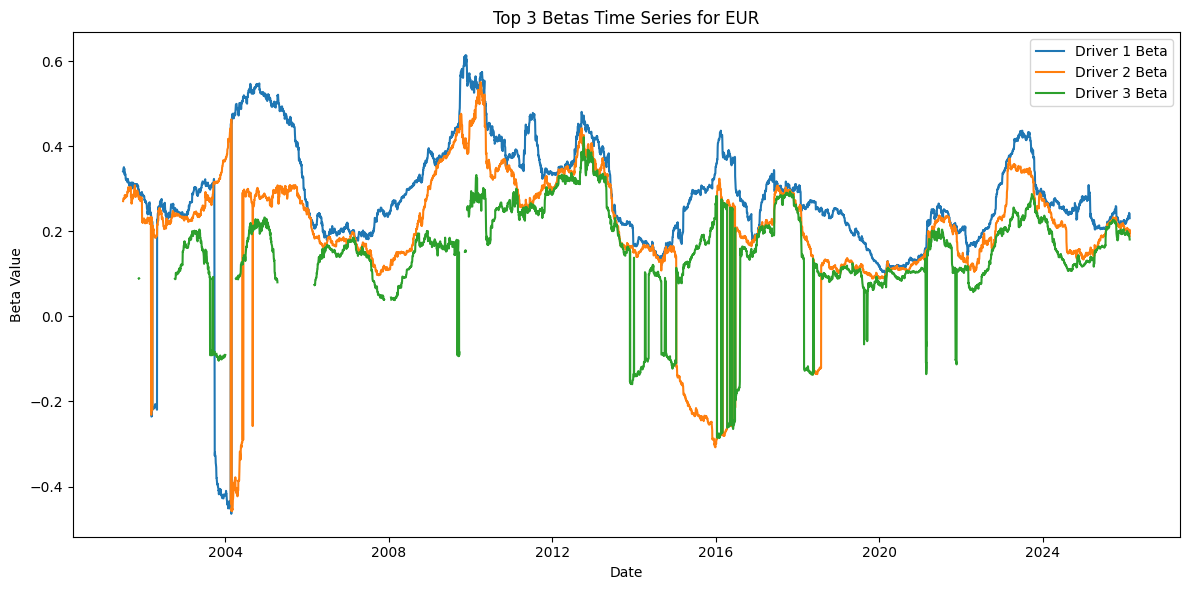

In [6]:
import matplotlib.pyplot as plt

# Choose the key you want to plot, e.g., "eur"
key = "eur"
df = top_map[key]

# Plot the three beta time series
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Driver 1 Beta"], label="Driver 1 Beta")
plt.plot(df.index, df["Driver 2 Beta"], label="Driver 2 Beta")
plt.plot(df.index, df["Driver 3 Beta"], label="Driver 3 Beta")
plt.xlabel("Date")
plt.ylabel("Beta Value")
plt.title(f"Top 3 Betas Time Series for {key.upper()}")
plt.legend()
plt.tight_layout()
plt.show()